# Palantir Cell Trajectory
**Kernel:** Python (palantir-venv)  
**Data:** `./data/Processed/CD8_DE2500_singleVDJ_emb.h5mu` — CD8 T cells, 14 957 cells × 2 500 HVGs, log-normalised.

**Subtypes:** CD8_Mitosis → CD8_Teff / CD8_Trm_exh_{L,M,H}  
**Start cell:** CD8_Mitosis edge cell (extreme DC1, proliferating progenitor).  
**Terminal states:** CD8_Teff (cytotoxic terminal), CD8_Trm_exh_H (deep exhaustion).

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
import h5py
import anndata as ad
import scanpy as sc
import palantir

sc.settings.verbosity = 1
sc.settings.set_figure_params(dpi=100, frameon=False)
print('palantir', palantir.__version__)
print('scanpy  ', sc.__version__)
print('anndata ', ad.__version__)

palantir 1.4.4
scanpy   1.11.5
anndata  0.11.4


## 1. Load GEX from h5mu
The venv does not include `muon`; we read the `gex` modality directly with `h5py`.

In [2]:
path = r"/ix1/ylee/Yifan_Zhang/Code_data/Tumor/GSE139555_2019/data/Processed/"
filename = "CD8_DE2500_singleVDJ_emb.h5mu"
DATA_PATH = path + filename

In [3]:
# import muon as mu
# mdata = mu.read(DATA_PATH)
# mdata
# adata_m= mdata['gex']

In [4]:

def load_gex_from_h5mu(path: str) -> ad.AnnData:
    """Read the 'gex' modality from an h5mu file without muon."""
    with h5py.File(path, "r") as f:
        g = f["mod"]["gex"]

        # ── X (CSR) ──────────────────────────────────────────────
        xg = g["X"]
        shape = tuple(xg.attrs["shape"].tolist())
        X = sp.csr_matrix(
            (xg["data"][:], xg["indices"][:], xg["indptr"][:]),
            shape=shape,
        )

        # ── obs ──────────────────────────────────────────────────
        obs_idx = [s.decode() for s in g["obs"]["_index"][:]]
        obs_dict = {}
        for col in g["obs"].keys():
            if col == "_index":
                continue
            col_data = g["obs"][col]
            if "categories" in col_data:
                cats = [s.decode() for s in col_data["categories"][:]]
                codes = col_data["codes"][:]
                obs_dict[col] = pd.Categorical.from_codes(codes, cats)
            else:
                vals = col_data[:]
                if vals.dtype.kind in ("S", "O"):
                    vals = [v.decode() if isinstance(v, bytes) else str(v) for v in vals]
                obs_dict[col] = vals
        obs = pd.DataFrame(obs_dict, index=obs_idx)

        # ── var ──────────────────────────────────────────────────
        var_idx = [s.decode() for s in g["var"]["_index"][:]]
        var_dict = {}
        for col in g["var"].keys():
            if col == "_index":
                continue
            col_data = g["var"][col]
            try:
                if "categories" in col_data:
                    cats = [s.decode() for s in col_data["categories"][:]]
                    codes = col_data["codes"][:]
                    var_dict[col] = pd.Categorical.from_codes(codes, cats)
                else:
                    v = col_data[:]
                    if v.dtype.kind in ("S", "O"):
                        v = [x.decode() if isinstance(x, bytes) else str(x) for x in v]
                    var_dict[col] = v
            except Exception:
                pass
        var = pd.DataFrame(var_dict, index=var_idx)

        # ── obsm ─────────────────────────────────────────────────
        obsm = {k: g["obsm"][k][:] for k in g["obsm"].keys()}

    adata = ad.AnnData(X=X, obs=obs, var=var)
    for k, v in obsm.items():
        adata.obsm[k] = v
    return adata


adata = load_gex_from_h5mu(DATA_PATH)
print(adata)
print("\nSubtypes:")
print(adata.obs["subtype"].value_counts())

AnnData object with n_obs × n_vars = 14957 × 2500
    obs: 'clone_status', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'log1p_total_counts_hb', 'log1p_total_counts_mt', 'log1p_total_counts_ribo', 'n_counts', 'n_genes', 'n_genes_by_counts', 'patient', 'pct_counts_hb', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'pct_counts_in_top_50_genes', 'pct_counts_mt', 'pct_counts_ribo', 'sample', 'source', 'subtype', 'total_counts', 'total_counts_hb', 'total_counts_mt', 'total_counts_ribo', 'type'
    var: 'dispersions', 'dispersions_norm', 'hb', 'highly_variable', 'highly_variable_intersection', 'highly_variable_nbatches', 'log1p_mean_counts', 'log1p_total_counts', 'mean_counts', 'means', 'mt', 'n_cells', 'n_cells_by_counts', 'pct_dropout_by_counts', 'ribo', 'total_counts'
    obsm: 'X_pca', 'X_umap'

Subtypes:
subtype
CD8_Tem          3747
CD8_Teff         3284
CD8_Trm_exh_L    2991
CD8_Trm_exh_H    2409
CD8_Trm_exh_M    1335
CD8_Mitosis     

## 2. Quick sanity check — existing UMAP

In [5]:
sc.pl.embedding(
    adata, basis="X_umap",
    color=["subtype", "source", "patient"],
    ncols=3, wspace=0.4, frameon=False,
)

## 3. Palantir preprocessing — diffusion maps
Data is already log-normalised (`uns['log1p']`) and PCA is stored in `obsm['X_pca']`.  
Palantir expects a PCA-reduced representation as input.

In [22]:
# pp
sc.pp.pca(adata, n_comps=50)
sc.pp.neighbors(adata, n_neighbors=10, use_rep='X_pca')

In [23]:
# Use stored PCA.  Palantir will compute its own diffusion maps from it.
pca_proj = adata.obsm["X_pca"]
print(f"PCA shape: {pca_proj.shape}")

# Build a temporary AnnData with PCA as X for Palantir's diffusion-map step
adata_pca = ad.AnnData(
    X=pca_proj.astype(np.float64),
    obs=adata.obs.copy(),
)
adata_pca.obsm["X_pca"] = pca_proj.astype(np.float64)
adata_pca.obsm["X_umap"] = adata.obsm["X_umap"]

# Compute diffusion maps
palantir.utils.run_diffusion_maps(
    adata_pca,
    pca_key="X_pca",
    n_components=20,
    knn=15,
    alpha=0.8
)
print("Diffusion map keys:", list(adata_pca.obsm.keys()))

PCA shape: (14957, 50)
Diffusion map keys: ['X_pca', 'X_umap', 'DM_EigenVectors']


In [24]:
print(adata_pca.uns['DM_EigenValues'])

[1.0000001  0.97404027 0.9627565  0.9554269  0.953573   0.9503021
 0.9465231  0.92664206 0.9217005  0.9134855  0.9038722  0.89340997
 0.8879671  0.8876101  0.8654672  0.8637296  0.8601208  0.8561466
 0.84976363 0.8416016 ]


In [8]:
adata_pca

AnnData object with n_obs × n_vars = 14957 × 10
    obs: 'clone_status', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'log1p_total_counts_hb', 'log1p_total_counts_mt', 'log1p_total_counts_ribo', 'n_counts', 'n_genes', 'n_genes_by_counts', 'patient', 'pct_counts_hb', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'pct_counts_in_top_50_genes', 'pct_counts_mt', 'pct_counts_ribo', 'sample', 'source', 'subtype', 'total_counts', 'total_counts_hb', 'total_counts_mt', 'total_counts_ribo', 'type'
    uns: 'DM_EigenValues'
    obsm: 'X_pca', 'X_umap', 'DM_EigenVectors'
    obsp: 'DM_Kernel', 'DM_Similarity'

In [ ]:
# sc.pp.neighbors(adata_pca)
# sc.tl.umap(adata_pca)


In [10]:
# %matplotlib widget
# import matplotlib
# matplotlib.use('TkAgg')
# import matplotlib.pyplot as plt
# import scanpy as sc
# import numpy as np

# fig, ax = plt.subplots()
# sc.pl.umap(adata, color='cell_type', ax=ax, show=False)

# def onclick(event):
#     x, y = event.xdata, event.ydata
#     if x is None:
#         return
#     coords = adata.obsm['X_umap']
#     dist = np.sqrt((coords[:,0]-x)**2 + (coords[:,1]-y)**2)
#     idx = np.argmin(dist)
#     print(f"Cell: {adata.obs_names[idx]}")
#     plt.close(fig)  # closes window after click

# fig.canvas.mpl_connect('button_press_event', onclick)
# plt.show()  # blocks until window is closed

In [12]:
# Multiscale space (used as the actual distance space for Palantir)
palantir.utils.determine_multiscale_space(adata_pca)
print("Multiscale space shape:", adata_pca.obsm["DM_EigenVectors_multiscaled"].shape)


Multiscale space shape: (14957, 2)


In [13]:
# Impute genes

# imputed_X = palantir.utils.run_magic_imputation(adata_pca)
# adata_pca

In [14]:

# Palantir stores diffusion eigenvectors in "DM_EigenVectors" (cols 0..n-1, no trivial component)
dm = adata_pca.obsm["DM_EigenVectors"]
for i in range(dm.shape[1]):
    adata_pca.obs[f"DC{i+1}"] = dm[:, i]

# min(4, dm.shape[1])

sc.pl.embedding(
    adata_pca, basis="X_umap",
    color=["subtype", "DC1", "DC2", "DC3"],
    ncols=2, wspace=0.4, frameon=False,
    color_map="RdBu_r",
)

In [15]:
aa

NameError: name 'aa' is not defined

## 4. Start & terminal cell selection
Pick a **CD8_Mitosis** cell at the edge of the cluster (extreme DC1) as the root,
and a **CD8_Trm_exh_H** cell at the deep-exhaustion edge as the terminal state.


In [ ]:
# Start cell: CD8_Mitosis cell most extreme along DC1 (edge of cluster)
mit_mask = adata_pca.obs['subtype'] == 'CD8_Mitosis'
print(f'CD8_Mitosis cells: {mit_mask.sum()}')

if mit_mask.sum() == 0:
    raise ValueError('No CD8_Mitosis cells found — check subtype labels')

dc1_mit = adata_pca.obs.loc[mit_mask, 'DC1']
# Edge = minimum DC1 in this cluster (adjust to idxmax if orientation is reversed)
start_cell = dc1_mit.idxmin()
print(f'Start cell: {start_cell}')
print(adata_pca.obs.loc[start_cell, ['subtype', 'source', 'DC1']])

# Terminal cell: CD8_Trm_exh_H cell most extreme along DC1
exh_mask = adata_pca.obs['subtype'] == 'CD8_Trm_exh_H'
print(f'\nCD8_Trm_exh_H cells: {exh_mask.sum()}')

if exh_mask.sum() == 0:
    raise ValueError('No CD8_Trm_exh_H cells found — check subtype labels')

dc1_exh = adata_pca.obs.loc[exh_mask, 'DC1']
terminal_cell = dc1_exh.idxmax()
print(f'Terminal cell: {terminal_cell}')
print(adata_pca.obs.loc[terminal_cell, ['subtype', 'source', 'DC1']])


CD8_Mitosis cells: 462
Start cell: RT1_TTCGAAGGTGAGGGTT-1
subtype    CD8_Mitosis
source           Tumor
DC1          -0.008177
Name: RT1_TTCGAAGGTGAGGGTT-1, dtype: object

CD8_Trm_exh_H cells: 2409
Terminal cell: LB6_ATGCGATCAACACCTA-1
subtype    CD8_Trm_exh_H
source             Blood
DC1            -0.008175
Name: LB6_ATGCGATCAACACCTA-1, dtype: object


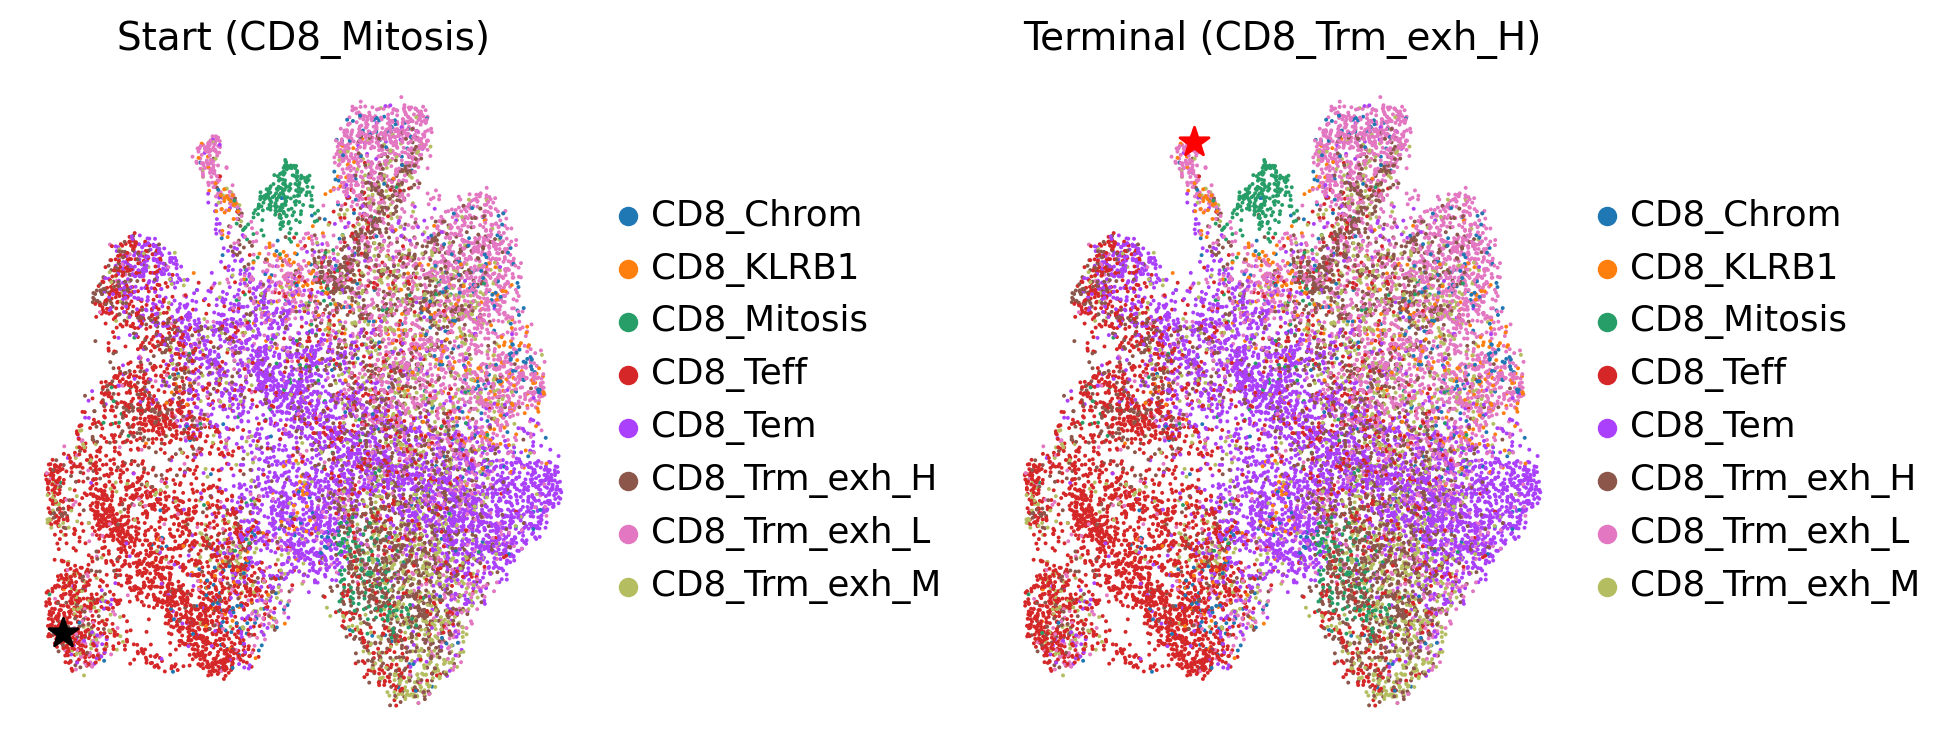

In [ ]:
adata_pca.obs['is_start']    = adata_pca.obs_names == start_cell
adata_pca.obs['is_terminal'] = adata_pca.obs_names == terminal_cell

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, cell, label, color in zip(
    axes,
    [start_cell, terminal_cell],
    ['Start (CD8_Mitosis)', 'Terminal (CD8_Trm_exh_H)'],
    ['black', 'red'],
):
    sc.pl.embedding(adata_pca, basis='X_umap', color='subtype',
                    ax=ax, show=False, frameon=False)
    xy = adata_pca.obsm['X_umap'][adata_pca.obs_names == cell][0]
    ax.scatter(*xy, s=120, marker='*', color=color, zorder=5, label=label)
    ax.set_title(label)
plt.tight_layout()
plt.show()


## 5. Run Palantir

In [ ]:
pr_res = palantir.core.run_palantir(
    adata_pca,
    early_cell=start_cell,
    terminal_states=[terminal_cell],
    use_early_cell_as_start=True,
    num_waypoints=1200,
)
print(pr_res)


Sampling and flocking waypoints...
Time for determining waypoints: 0.0010061462720235188 minutes
Determining pseudotime...
Shortest path distances using 30-nearest neighbor graph...
Time for shortest paths: 0.31546778281529747 minutes
Iteratively refining the pseudotime...
Correlation at iteration 1: 1.0000
Entropy and branch probabilities...
Markov chain construction...
Computing fundamental matrix and absorption probabilities...
Project results to all cells...


## 6. Visualise Palantir results

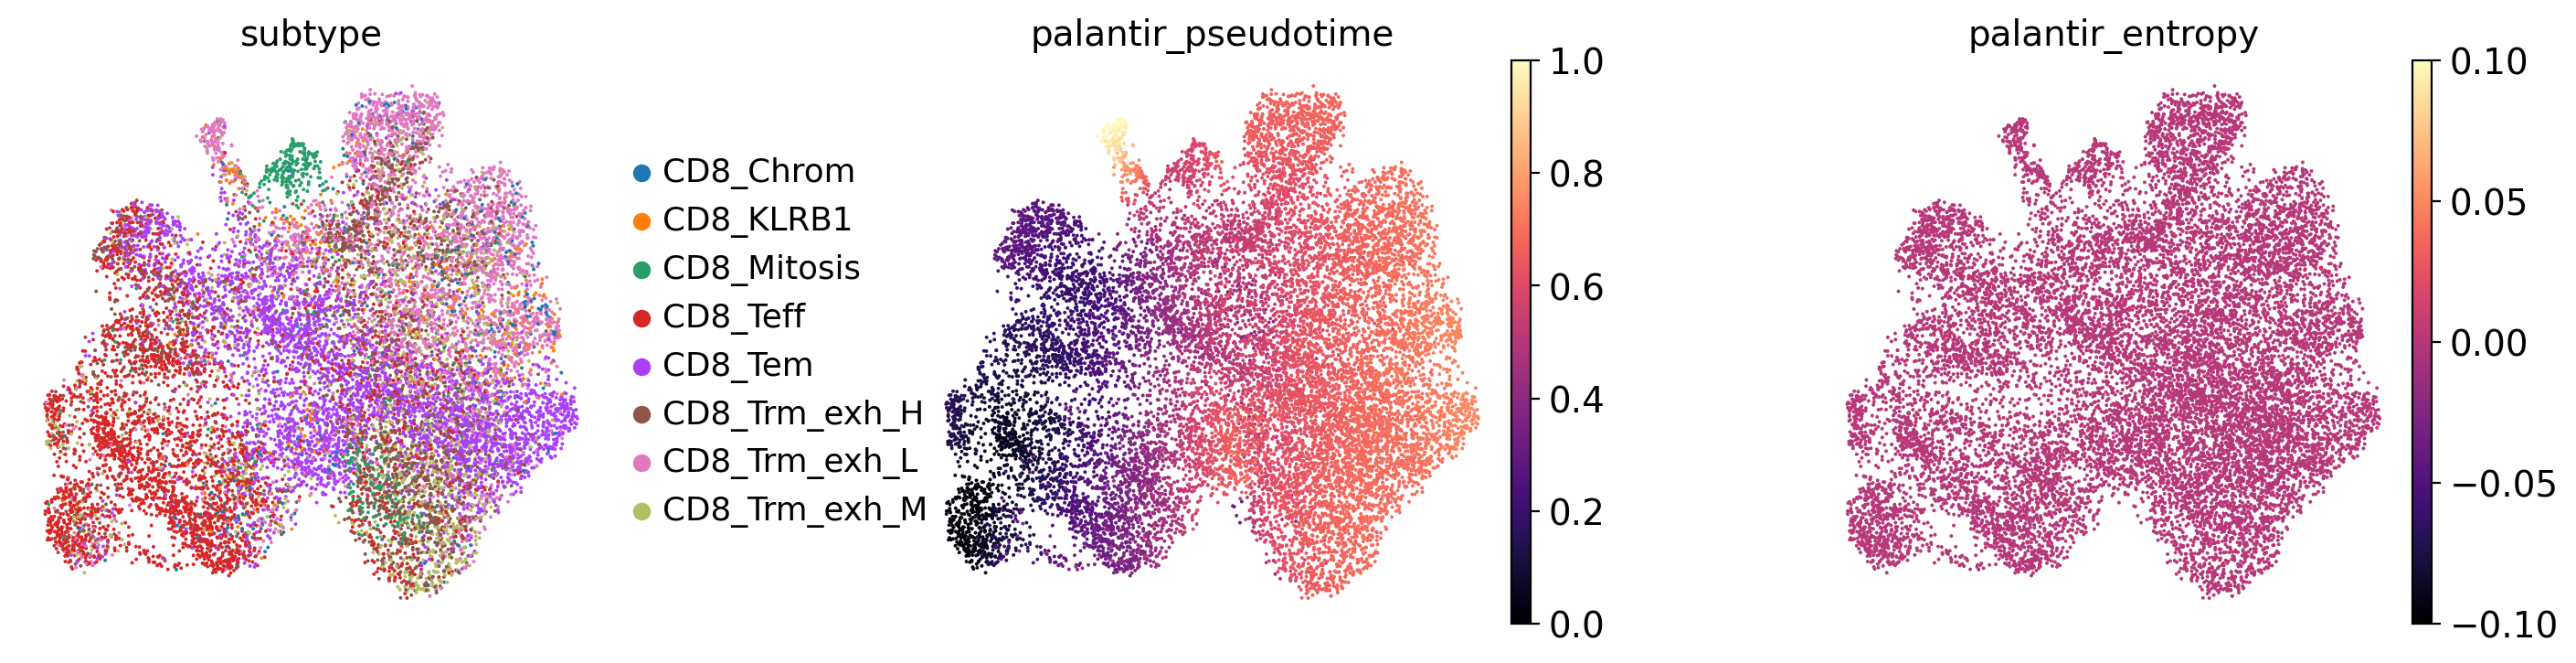

In [ ]:
# Copy pseudotime and entropy back for scanpy plotting
adata_pca.obs["palantir_pseudotime"] = pr_res.pseudotime
adata_pca.obs["palantir_entropy"]    = pr_res.entropy

sc.pl.embedding(
    adata_pca, basis="X_umap",
    color=["subtype", "palantir_pseudotime", "palantir_entropy"],
    ncols=3, wspace=0.4, frameon=False,
    color_map="magma",
)

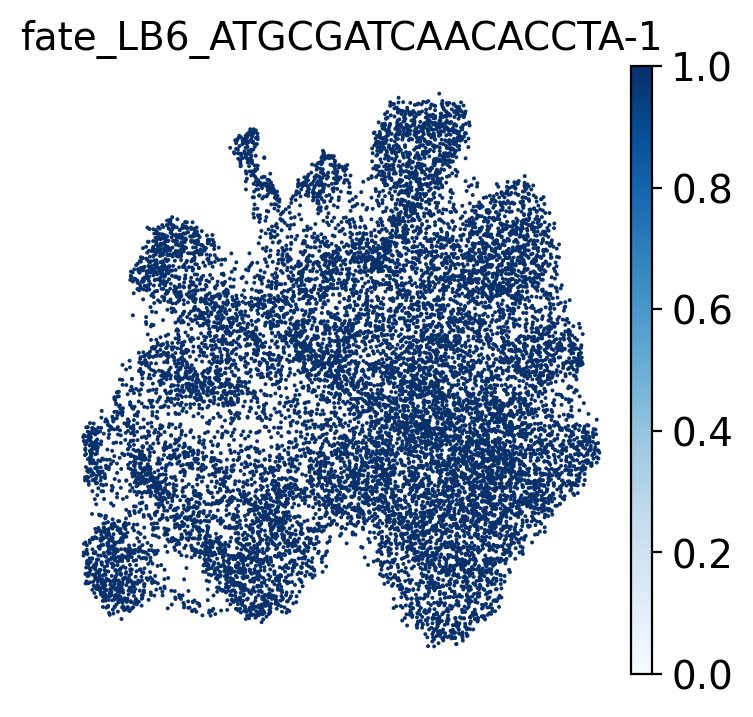

In [ ]:
# Per-terminal-state fate probabilities
for term in pr_res.branch_probs.columns:
    col = f"fate_{term}"
    adata_pca.obs[col] = pr_res.branch_probs[term].values

fate_cols = [c for c in adata_pca.obs.columns if c.startswith("fate_")]
sc.pl.embedding(
    adata_pca, basis="X_umap",
    color=fate_cols,
    ncols=min(3, len(fate_cols)),
    wspace=0.4, frameon=False,
    color_map="Blues",
    vmin=0, vmax=1,
)

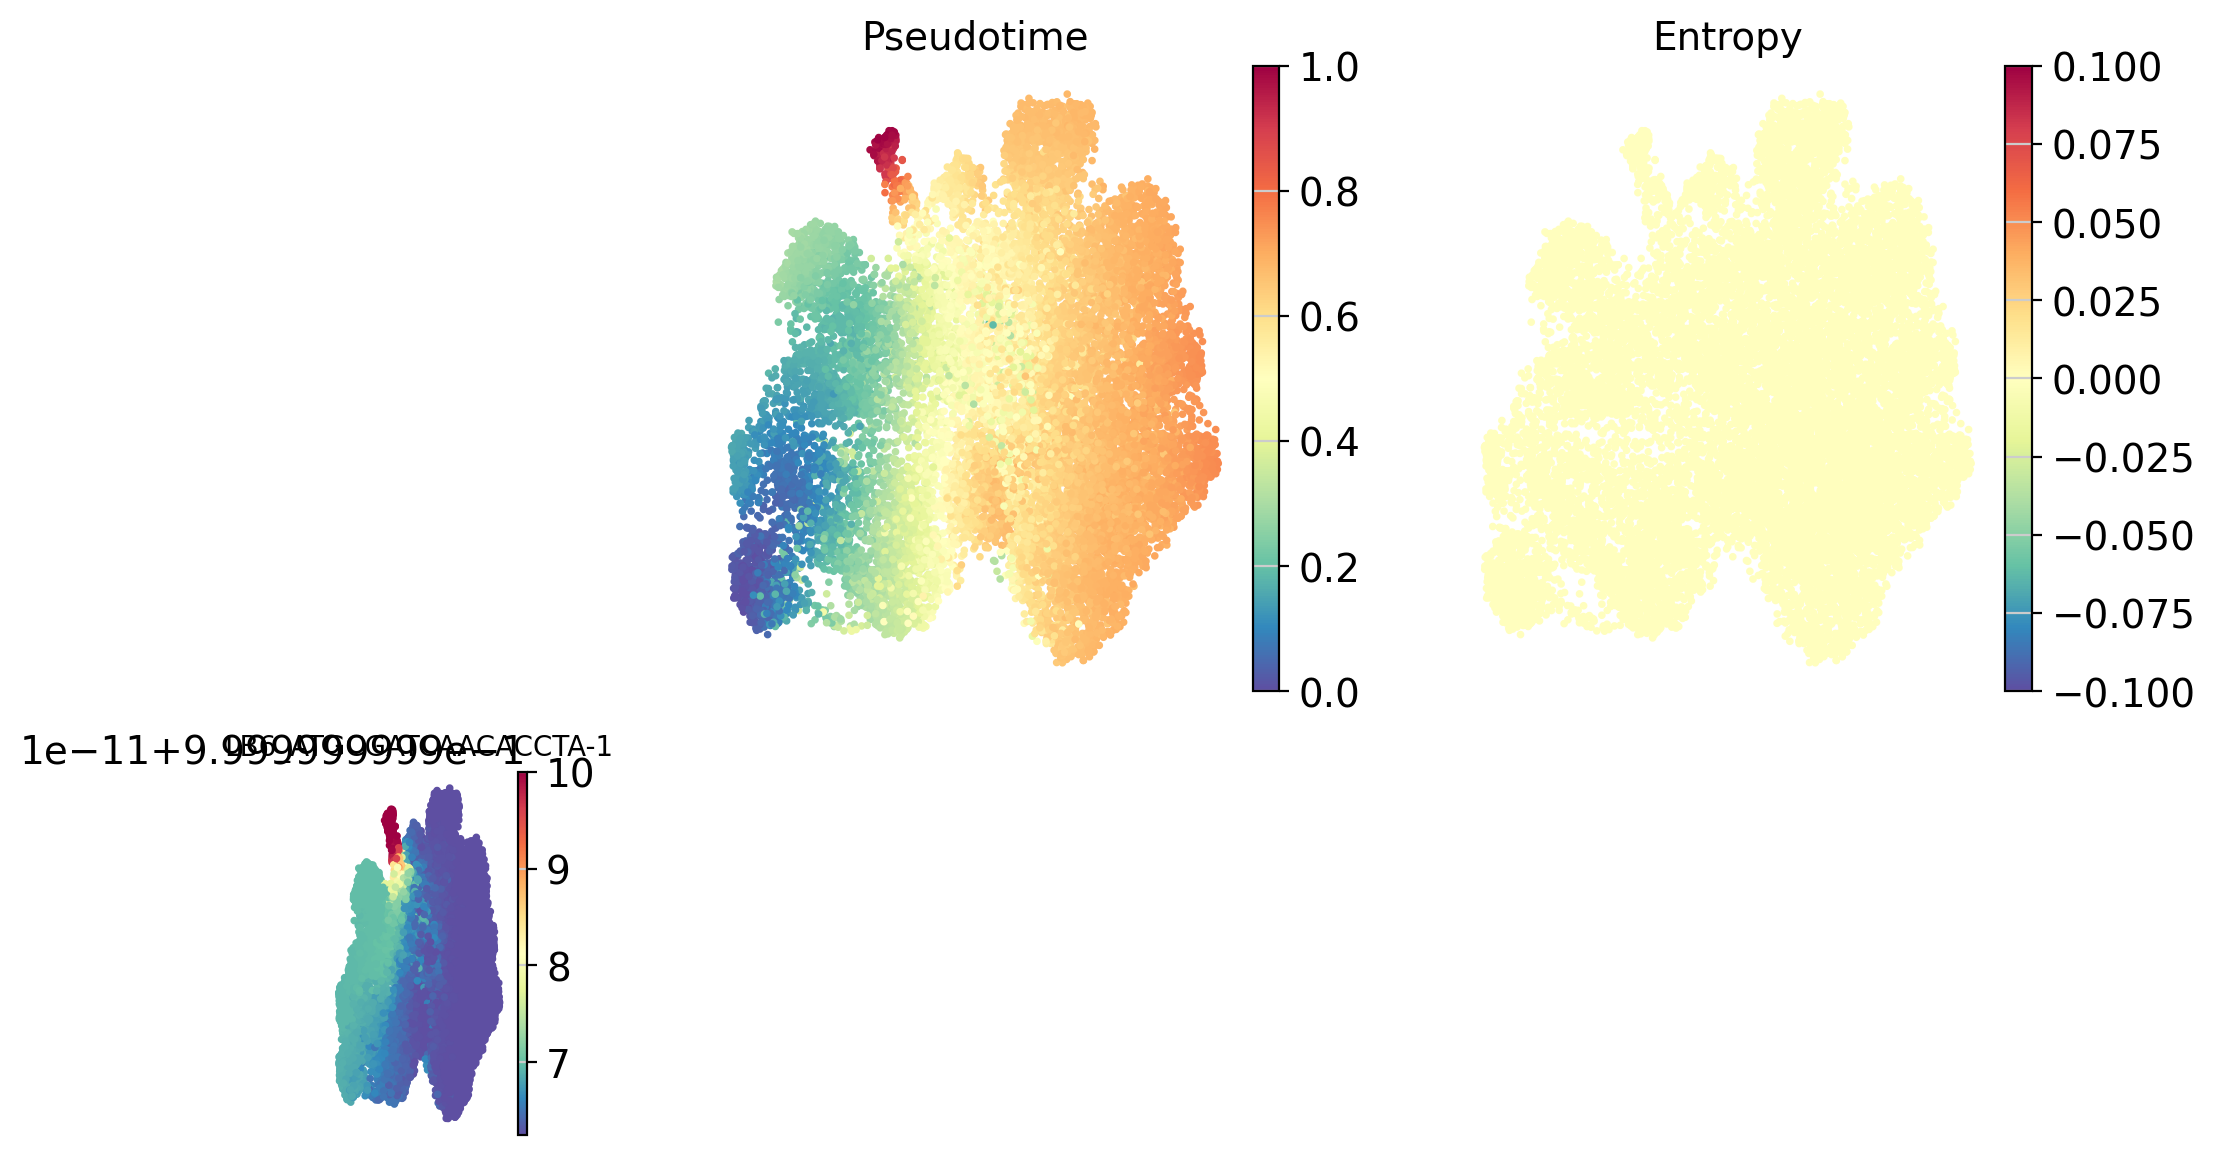

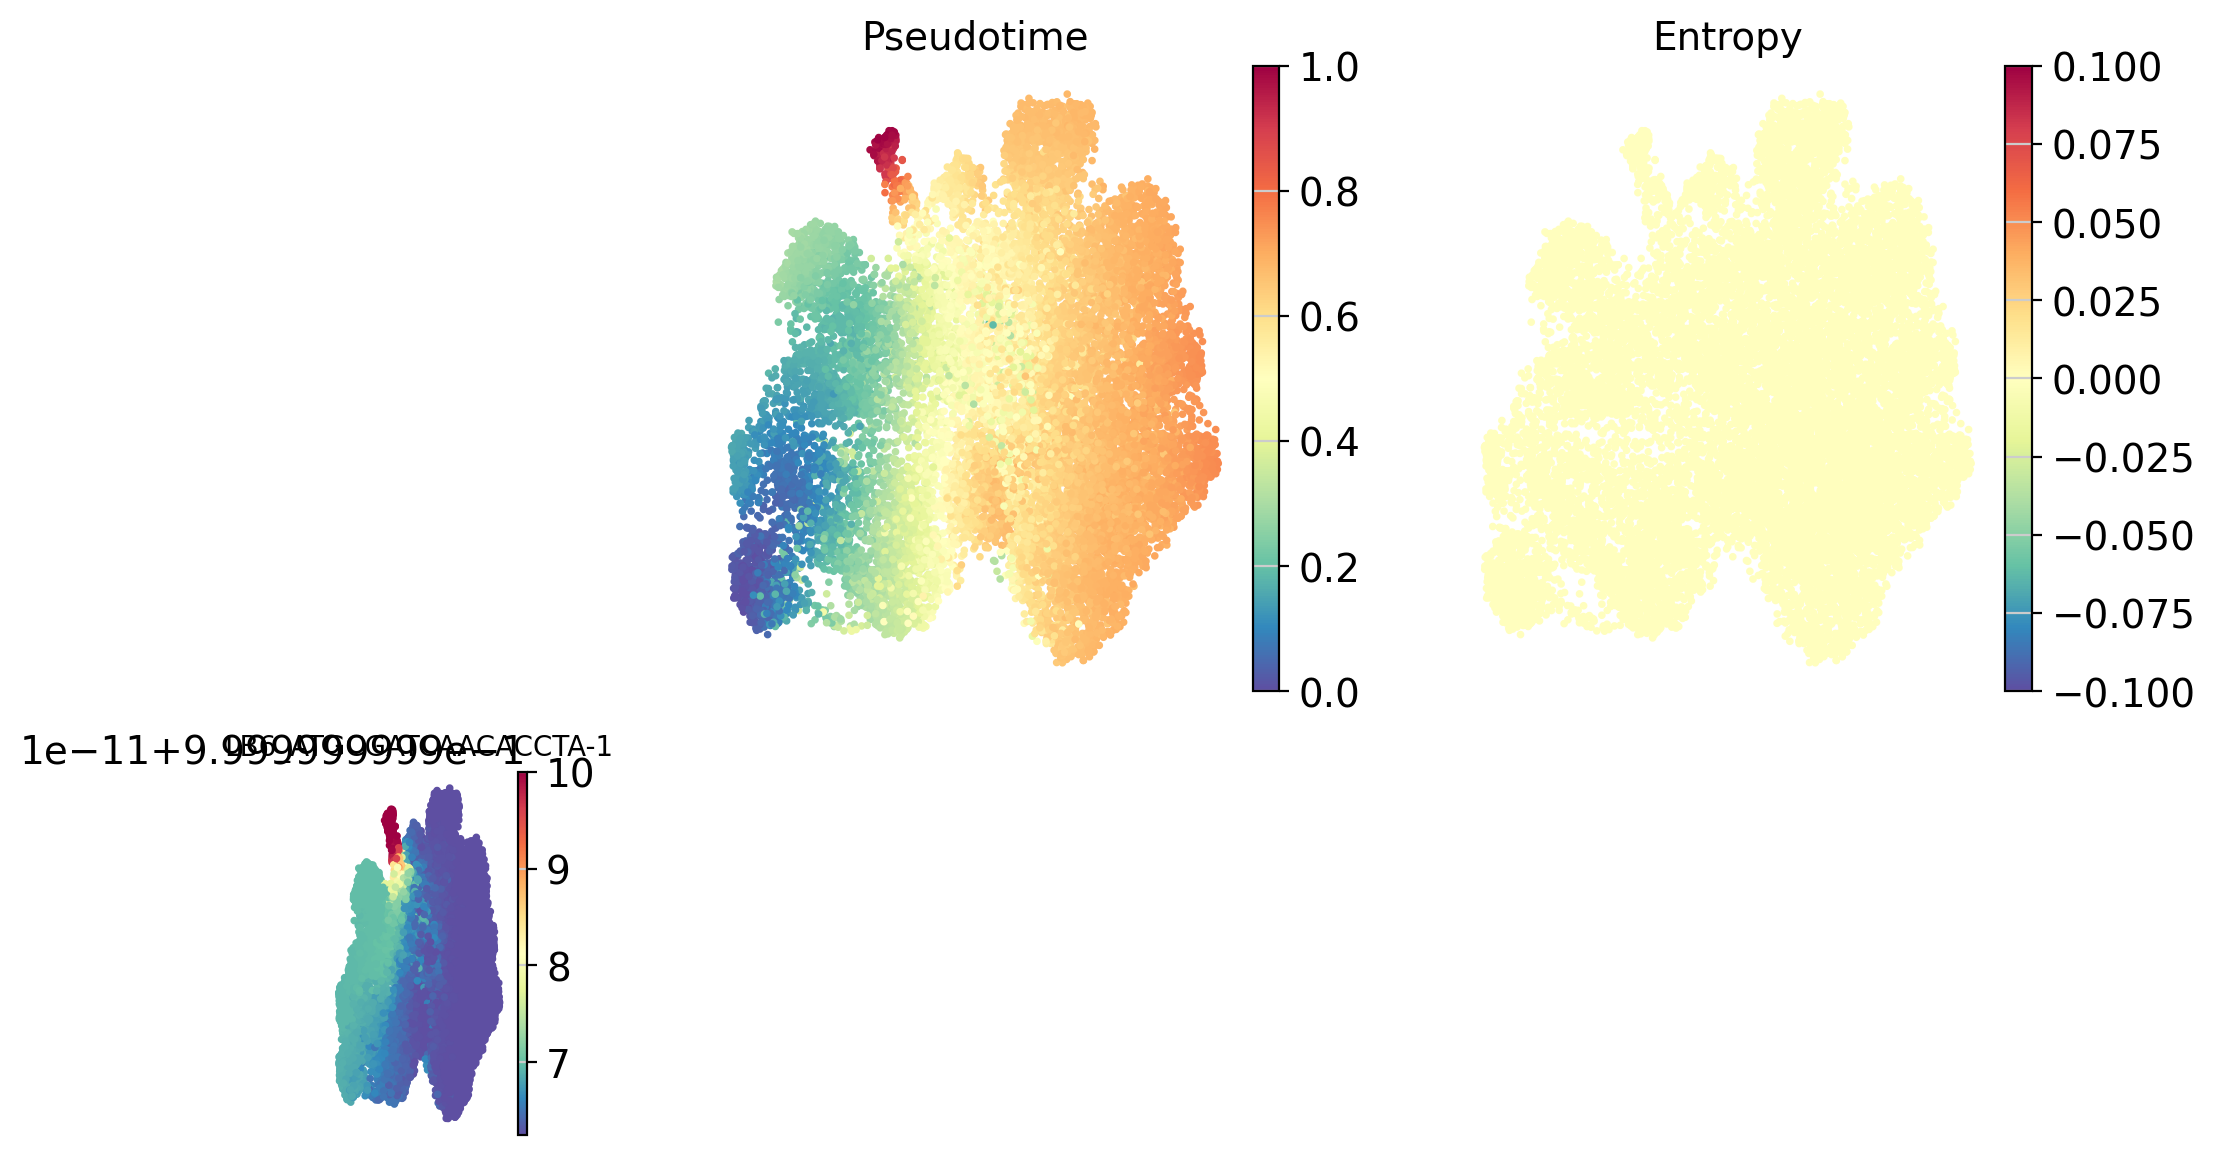

In [ ]:
# Palantir built-in result plot
palantir.plot.plot_palantir_results(adata_pca, s=3)

## 7. Pseudotime distribution by subtype

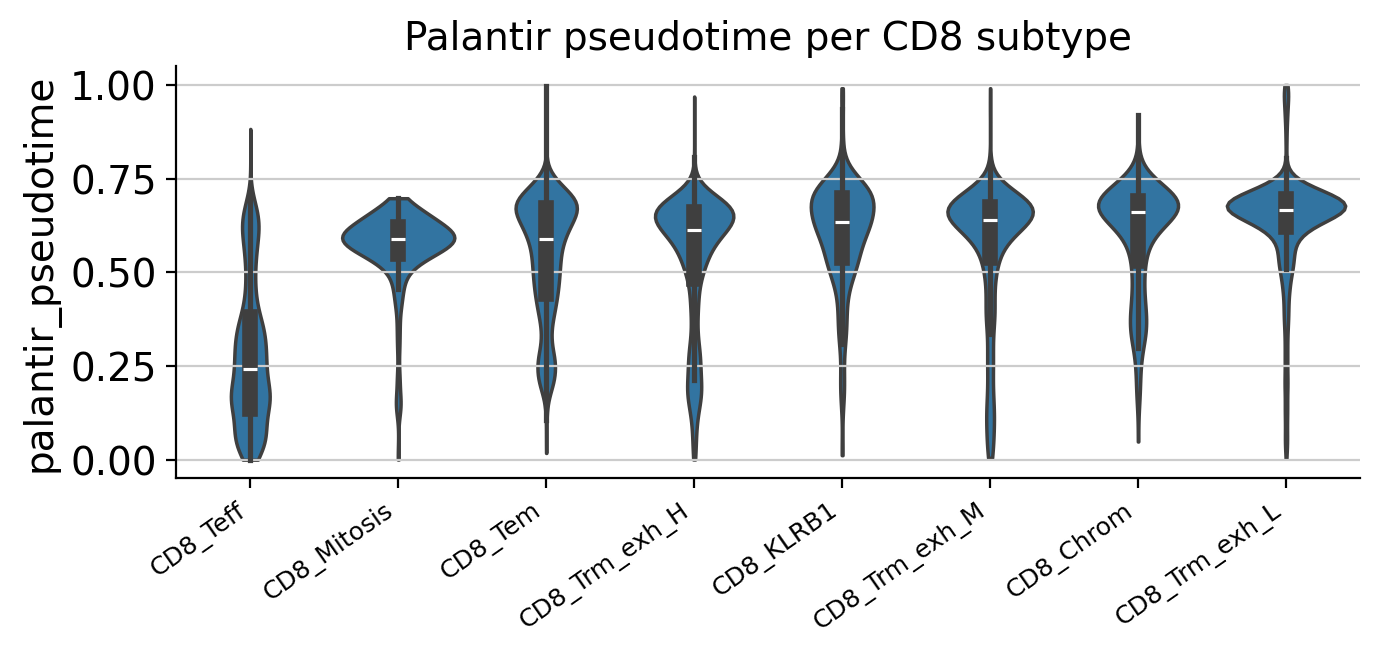

In [ ]:
import seaborn as sns

order = (
    adata_pca.obs.groupby("subtype")["palantir_pseudotime"]
    .median()
    .sort_values()
    .index.tolist()
)

fig, ax = plt.subplots(figsize=(7, 3.5))
sns.violinplot(
    data=adata_pca.obs,
    x="subtype", y="palantir_pseudotime",
    order=order, cut=0, inner="box", ax=ax,
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right", fontsize=9)
ax.set_title("Palantir pseudotime per CD8 subtype")
ax.set_xlabel("")
plt.tight_layout()
plt.show()

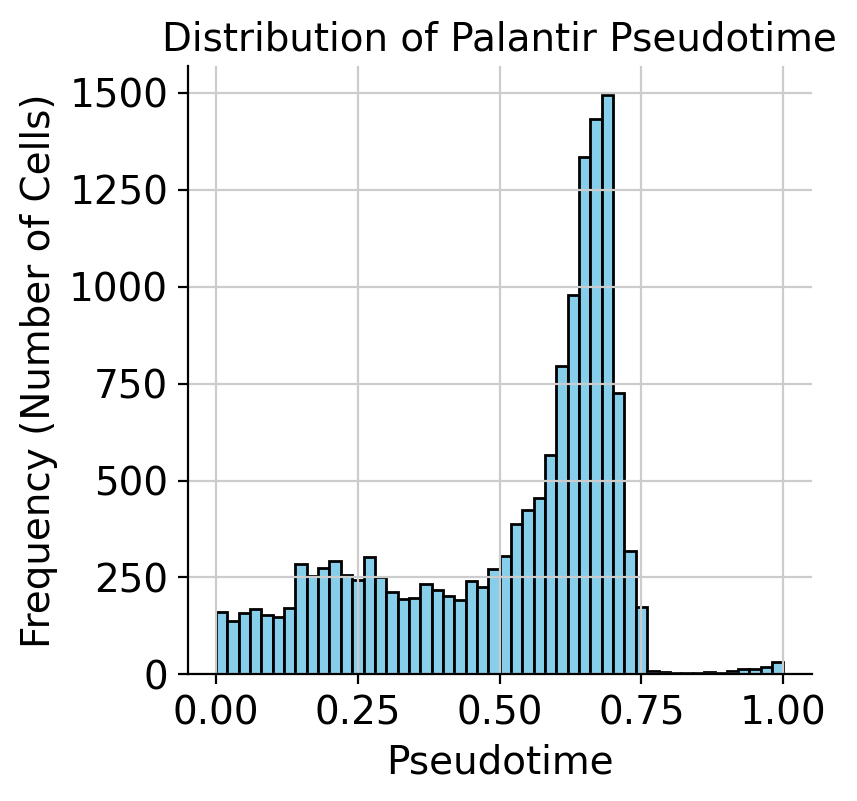

In [ ]:
import matplotlib.pyplot as plt

# Plot the histogram with 50 bins
adata_pca.obs['palantir_pseudotime'].plot.hist(bins=50, color='skyblue', edgecolor='black')

plt.title('Distribution of Palantir Pseudotime')
plt.xlabel('Pseudotime')
plt.ylabel('Frequency (Number of Cells)')
plt.show()

In [ ]:
adata_pca

AnnData object with n_obs × n_vars = 14957 × 10
    obs: 'clone_status', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'log1p_total_counts_hb', 'log1p_total_counts_mt', 'log1p_total_counts_ribo', 'n_counts', 'n_genes', 'n_genes_by_counts', 'patient', 'pct_counts_hb', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'pct_counts_in_top_50_genes', 'pct_counts_mt', 'pct_counts_ribo', 'sample', 'source', 'subtype', 'total_counts', 'total_counts_hb', 'total_counts_mt', 'total_counts_ribo', 'type', 'DC1', 'DC2', 'DC3', 'DC4', 'is_start', 'is_terminal', 'palantir_pseudotime', 'palantir_entropy', 'fate_LB6_ATGCGATCAACACCTA-1', 'macrostates_fwd', 'term_states_fwd', 'term_states_fwd_probs', 'clusters_gradients'
    uns: 'DM_EigenValues', 'neighbors', 'umap', 'subtype_colors', 'palantir_waypoints', 'schur_matrix_fwd', 'eigendecomposition_fwd', 'macrostates_fwd_colors', 'coarse_fwd', 'term_states_fwd_colors', 'clusters_gradients_colors', 'T_fwd_params'

### save 

In [ ]:
new_filename = filename.replace('.h5mu', '_pseudo.h5ad')
adata_pca.write_h5ad(path + new_filename)

In [ ]:
new_filename

'CD8_DE2500_singleVDJ_emb_pseudo.h5ad'

## 8. CellRank — Transition Matrix & Macrostates
Uses **CellRank 2** (`PseudotimeKernel` + `ConnectivityKernel` → `GPCCA`) to identify
macrostates, predict terminal states, compute fate probabilities, and find lineage-driver genes.
The Palantir pseudotime computed above is used as the time ordering.

In [ ]:
import cellrank as cr
from cellrank.kernels import PseudotimeKernel, ConnectivityKernel
from cellrank.estimators import GPCCA

print('cellrank', cr.__version__)


cellrank 2.0.7


In [ ]:
# PseudotimeKernel: transition probabilities derived from Palantir pseudotime
pk = PseudotimeKernel(adata_pca, time_key="palantir_pseudotime")
pk.compute_transition_matrix()
pk


100%|██████████| 14957/14957 [00:07<00:00, 2002.24cell/s]


PseudotimeKernel[n=14957, dnorm=False, scheme='hard', frac_to_keep=0.3]

100%|██████████| 100/100 [00:06<00:00, 16.32sim/s]


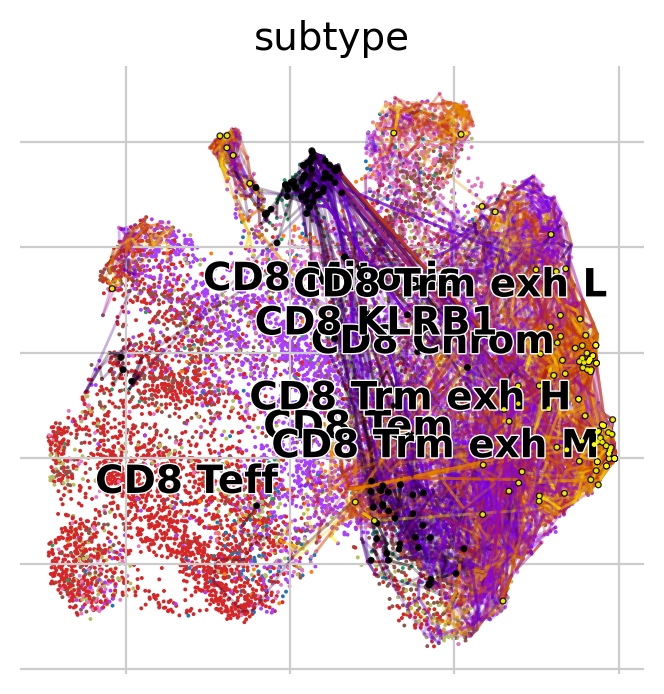

In [ ]:
pk.plot_random_walks(
    seed=0,
    n_sims=100,
    start_ixs={'subtype': 'CD8_Mitosis'},
    basis='X_umap',
    max_iter=200,
    legend_loc='on data',
    color='subtype',
)


In [ ]:
# ConnectivityKernel: uses the kNN graph from sc.pp.neighbors
ck = ConnectivityKernel(adata_pca).compute_transition_matrix()

# Combine: 80 % pseudotime-directed + 20 % graph connectivity
combined_kernel = 0.8 * pk + 0.2 * ck
combined_kernel


(0.8 * PseudotimeKernel[n=14957, dnorm=False, scheme='hard', frac_to_keep=0.3] + 0.2 * ConnectivityKernel[n=14957, dnorm=True, key='connectivities'])

In [ ]:
g = GPCCA(combined_kernel)
g.compute_schur(n_components=15)


GPCCA[kernel=(0.8 * PseudotimeKernel[n=14957] + 0.2 * ConnectivityKernel[n=14957]), initial_states=None, terminal_states=None]

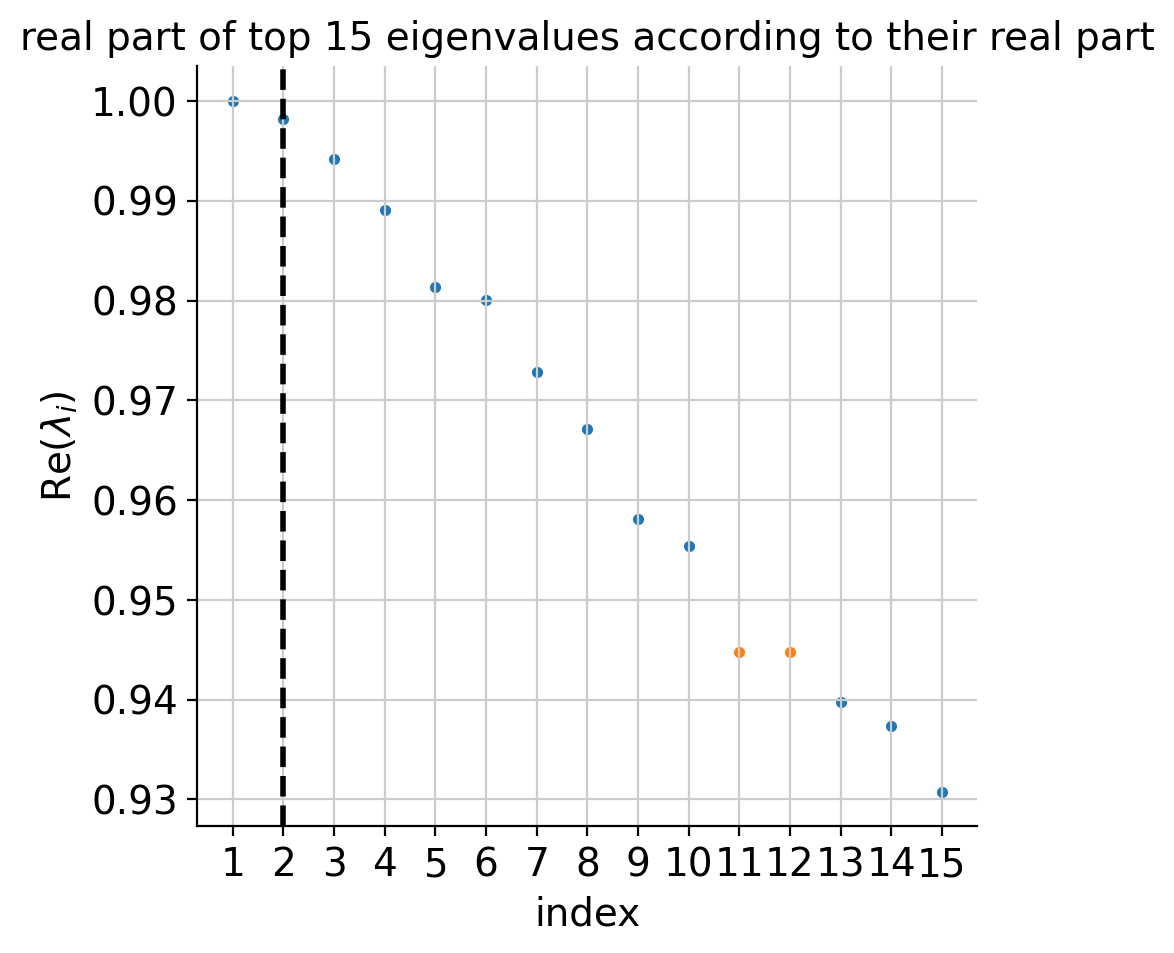

In [ ]:
g.plot_spectrum(real_only=True)


/ihome/ylee/yiz133/envs/cellrank/lib/python3.10/site-packages/scvelo/plotting/scatter.py:656: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  smp = ax.scatter(
/ihome/ylee/yiz133/envs/cellrank/lib/python3.10/site-packages/scvelo/plotting/scatter.py:694: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(
/ihome/ylee/yiz133/envs/cellrank/lib/python3.10/site-packages/scvelo/plotting/utils.py:1400: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(x, y, s=bg_size, marker=".", c=bg_color, zorder=zord - 2, **kwargs)
/ihome/ylee/yiz133/envs/cellrank/lib/python3.10/site-packages/scvelo/plotting/utils.py:1401: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(x, y, s=gp_size, marker=".", c=gp_color, zorder=zord - 1, **kwargs)


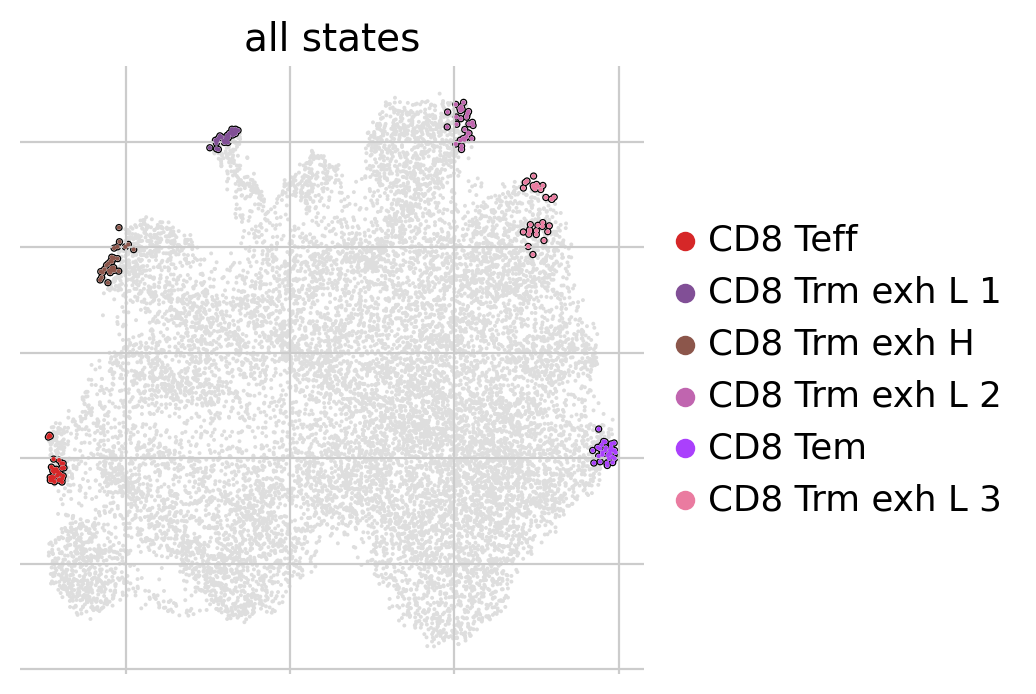

In [ ]:
# n_states chosen to cover CD8 subtypes; adjust based on the eigenvalue spectrum above
g.compute_macrostates(n_states=6, cluster_key="subtype")
g.plot_macrostates(which="all", basis="X_umap", legend_loc="right")


/ihome/ylee/yiz133/envs/cellrank/lib/python3.10/site-packages/scvelo/plotting/scatter.py:656: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  smp = ax.scatter(
/ihome/ylee/yiz133/envs/cellrank/lib/python3.10/site-packages/scvelo/plotting/scatter.py:694: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(
/ihome/ylee/yiz133/envs/cellrank/lib/python3.10/site-packages/scvelo/plotting/utils.py:1400: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(x, y, s=bg_size, marker=".", c=bg_color, zorder=zord - 2, **kwargs)
/ihome/ylee/yiz133/envs/cellrank/lib/python3.10/site-packages/scvelo/plotting/utils.py:1401: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(x, y, s=gp_size, marker=".", c=gp_color, zorder=zord - 1, **kwargs)


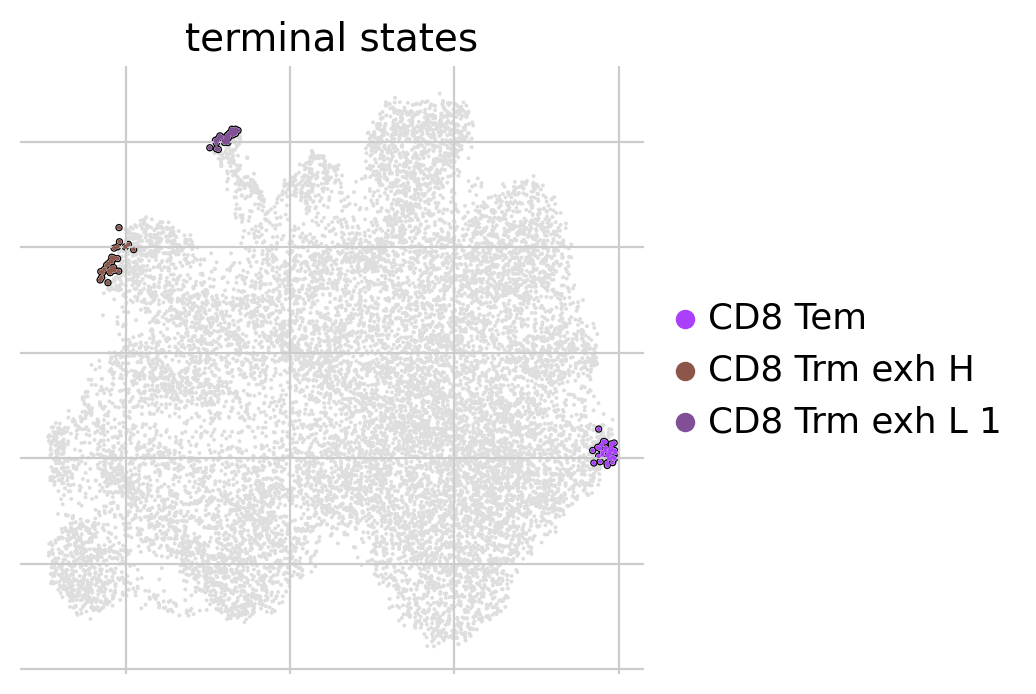

In [ ]:
g.predict_terminal_states(method="top_n", n_states=3)
g.plot_macrostates(which="terminal", basis="X_umap", legend_loc="right")


Defaulting to `'gmres'` solver.


100%|██████████| 3/3 [00:00<00:00,  6.96/s]
/ihome/ylee/yiz133/envs/cellrank/lib/python3.10/site-packages/scvelo/plotting/scatter.py:656: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  smp = ax.scatter(
/ihome/ylee/yiz133/envs/cellrank/lib/python3.10/site-packages/scvelo/plotting/scatter.py:656: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  smp = ax.scatter(


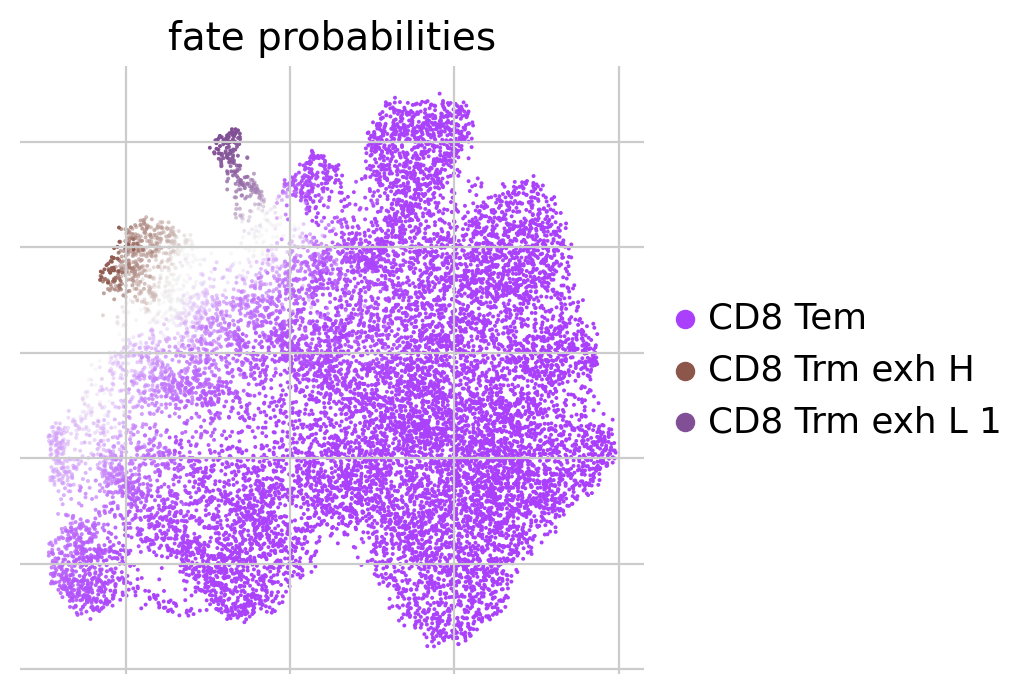

In [ ]:
g.compute_fate_probabilities()
g.plot_fate_probabilities(legend_loc="right", basis="X_umap")


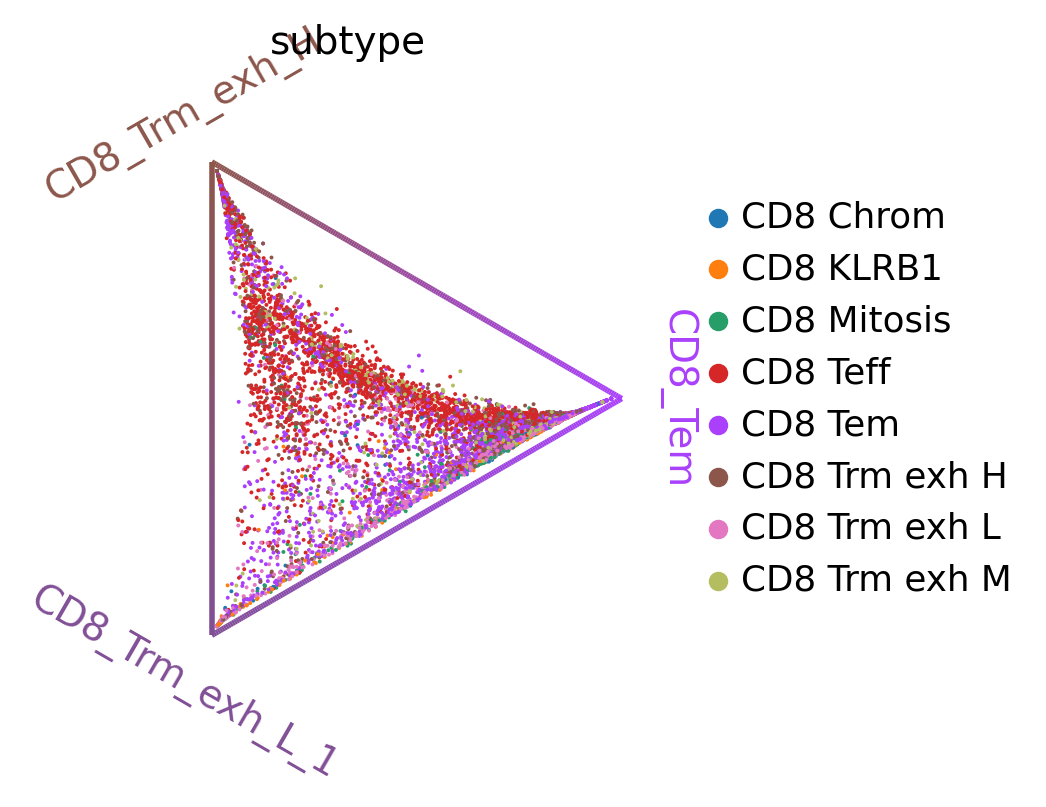

In [ ]:
cr.pl.circular_projection(adata_pca, keys="subtype", legend_loc="right")


In [ ]:
# Write transition matrix + GPCCA results (branch_masks, lineages_fwd, etc.) into adata_pca
pk.write_to_adata(key="T_fwd")
# g.write_to_adata()   # writes branch_masks, lineages_fwd, term-state obs cols

# Copy all CellRank obsm/uns keys from adata_pca -> adata (full GEX).
# We copy lineages_*, branch_masks, T_fwd so downstream cr.pl calls work on adata.
_CR_OBS_PREFIXES = ("lineages", "branch", "T_fwd")
pos = adata_pca.obs_names.get_indexer(adata.obs_names)  # int positions
for _k in list(adata_pca.obsm):
    if any(_k.startswith(p) for p in _CR_OBS_PREFIXES):
        adata.obsm[_k] = adata_pca.obsm[_k][pos]
for _k in list(adata_pca.uns):
    if any(_k.startswith(p) for p in _CR_OBS_PREFIXES) or _k in ("lineages_fwd_colors",):
        adata.uns[_k] = adata_pca.uns[_k]
# Also copy terminal/macrostate obs columns so cr.pl can colour cells
for _col in adata_pca.obs.columns:
    if any(_col.startswith(p) for p in ("terminal", "macrostate", "lineage")):
        adata.obs[_col] = adata_pca.obs[_col].reindex(adata.obs_names).values

terminal_lineages = list(g.terminal_states.cat.categories)
print("Terminal lineages:", terminal_lineages)

driver_tables = {}
for lineage in terminal_lineages:
    try:
        drivers = g.compute_lineage_drivers(
            lineages=lineage,
            return_drivers=True,
        )
        driver_tables[lineage] = drivers
        print(f'\n=== Top drivers -> {lineage} ===')
        print(drivers.head(10).to_string())
    except Exception as exc:
        print(f'Skipped {lineage}: {exc}')


Terminal lineages: [np.str_('CD8_Tem'), np.str_('CD8_Trm_exh_H'), np.str_('CD8_Trm_exh_L_1')]

=== Top drivers -> CD8_Tem ===
   CD8_Tem_corr   CD8_Tem_pval   CD8_Tem_qval  CD8_Tem_ci_low  CD8_Tem_ci_high
0      0.595102   0.000000e+00   0.000000e+00        0.584652         0.605355
2      0.232097  9.163288e-184  4.581644e-183        0.216878         0.247204
9      0.144736   4.563571e-71   1.521190e-70        0.129009         0.160391
8      0.043786   8.423738e-08   1.684748e-07        0.027779         0.059770
1      0.035576   1.346974e-05   2.244957e-05        0.019561         0.051573
4      0.022847   5.200562e-03   5.778402e-03        0.006823         0.038859
7     -0.008613   2.922175e-01   2.922175e-01       -0.024636         0.007414
5     -0.023421   4.176010e-03   5.220013e-03       -0.039432        -0.007397
3     -0.032245   7.997290e-05   1.142470e-04       -0.048246        -0.016227
6     -0.141306   8.809151e-68   2.202288e-67       -0.156977        -0.125564

=== 

Genes available for trends: ['TCF7', 'LEF1', 'SELL', 'GZMB', 'PRF1', 'CX3CR1', 'PDCD1', 'HAVCR2', 'TOX', 'ENTPD1']


100%|██████████| 6/6 [00:01<00:00,  3.60gene/s]


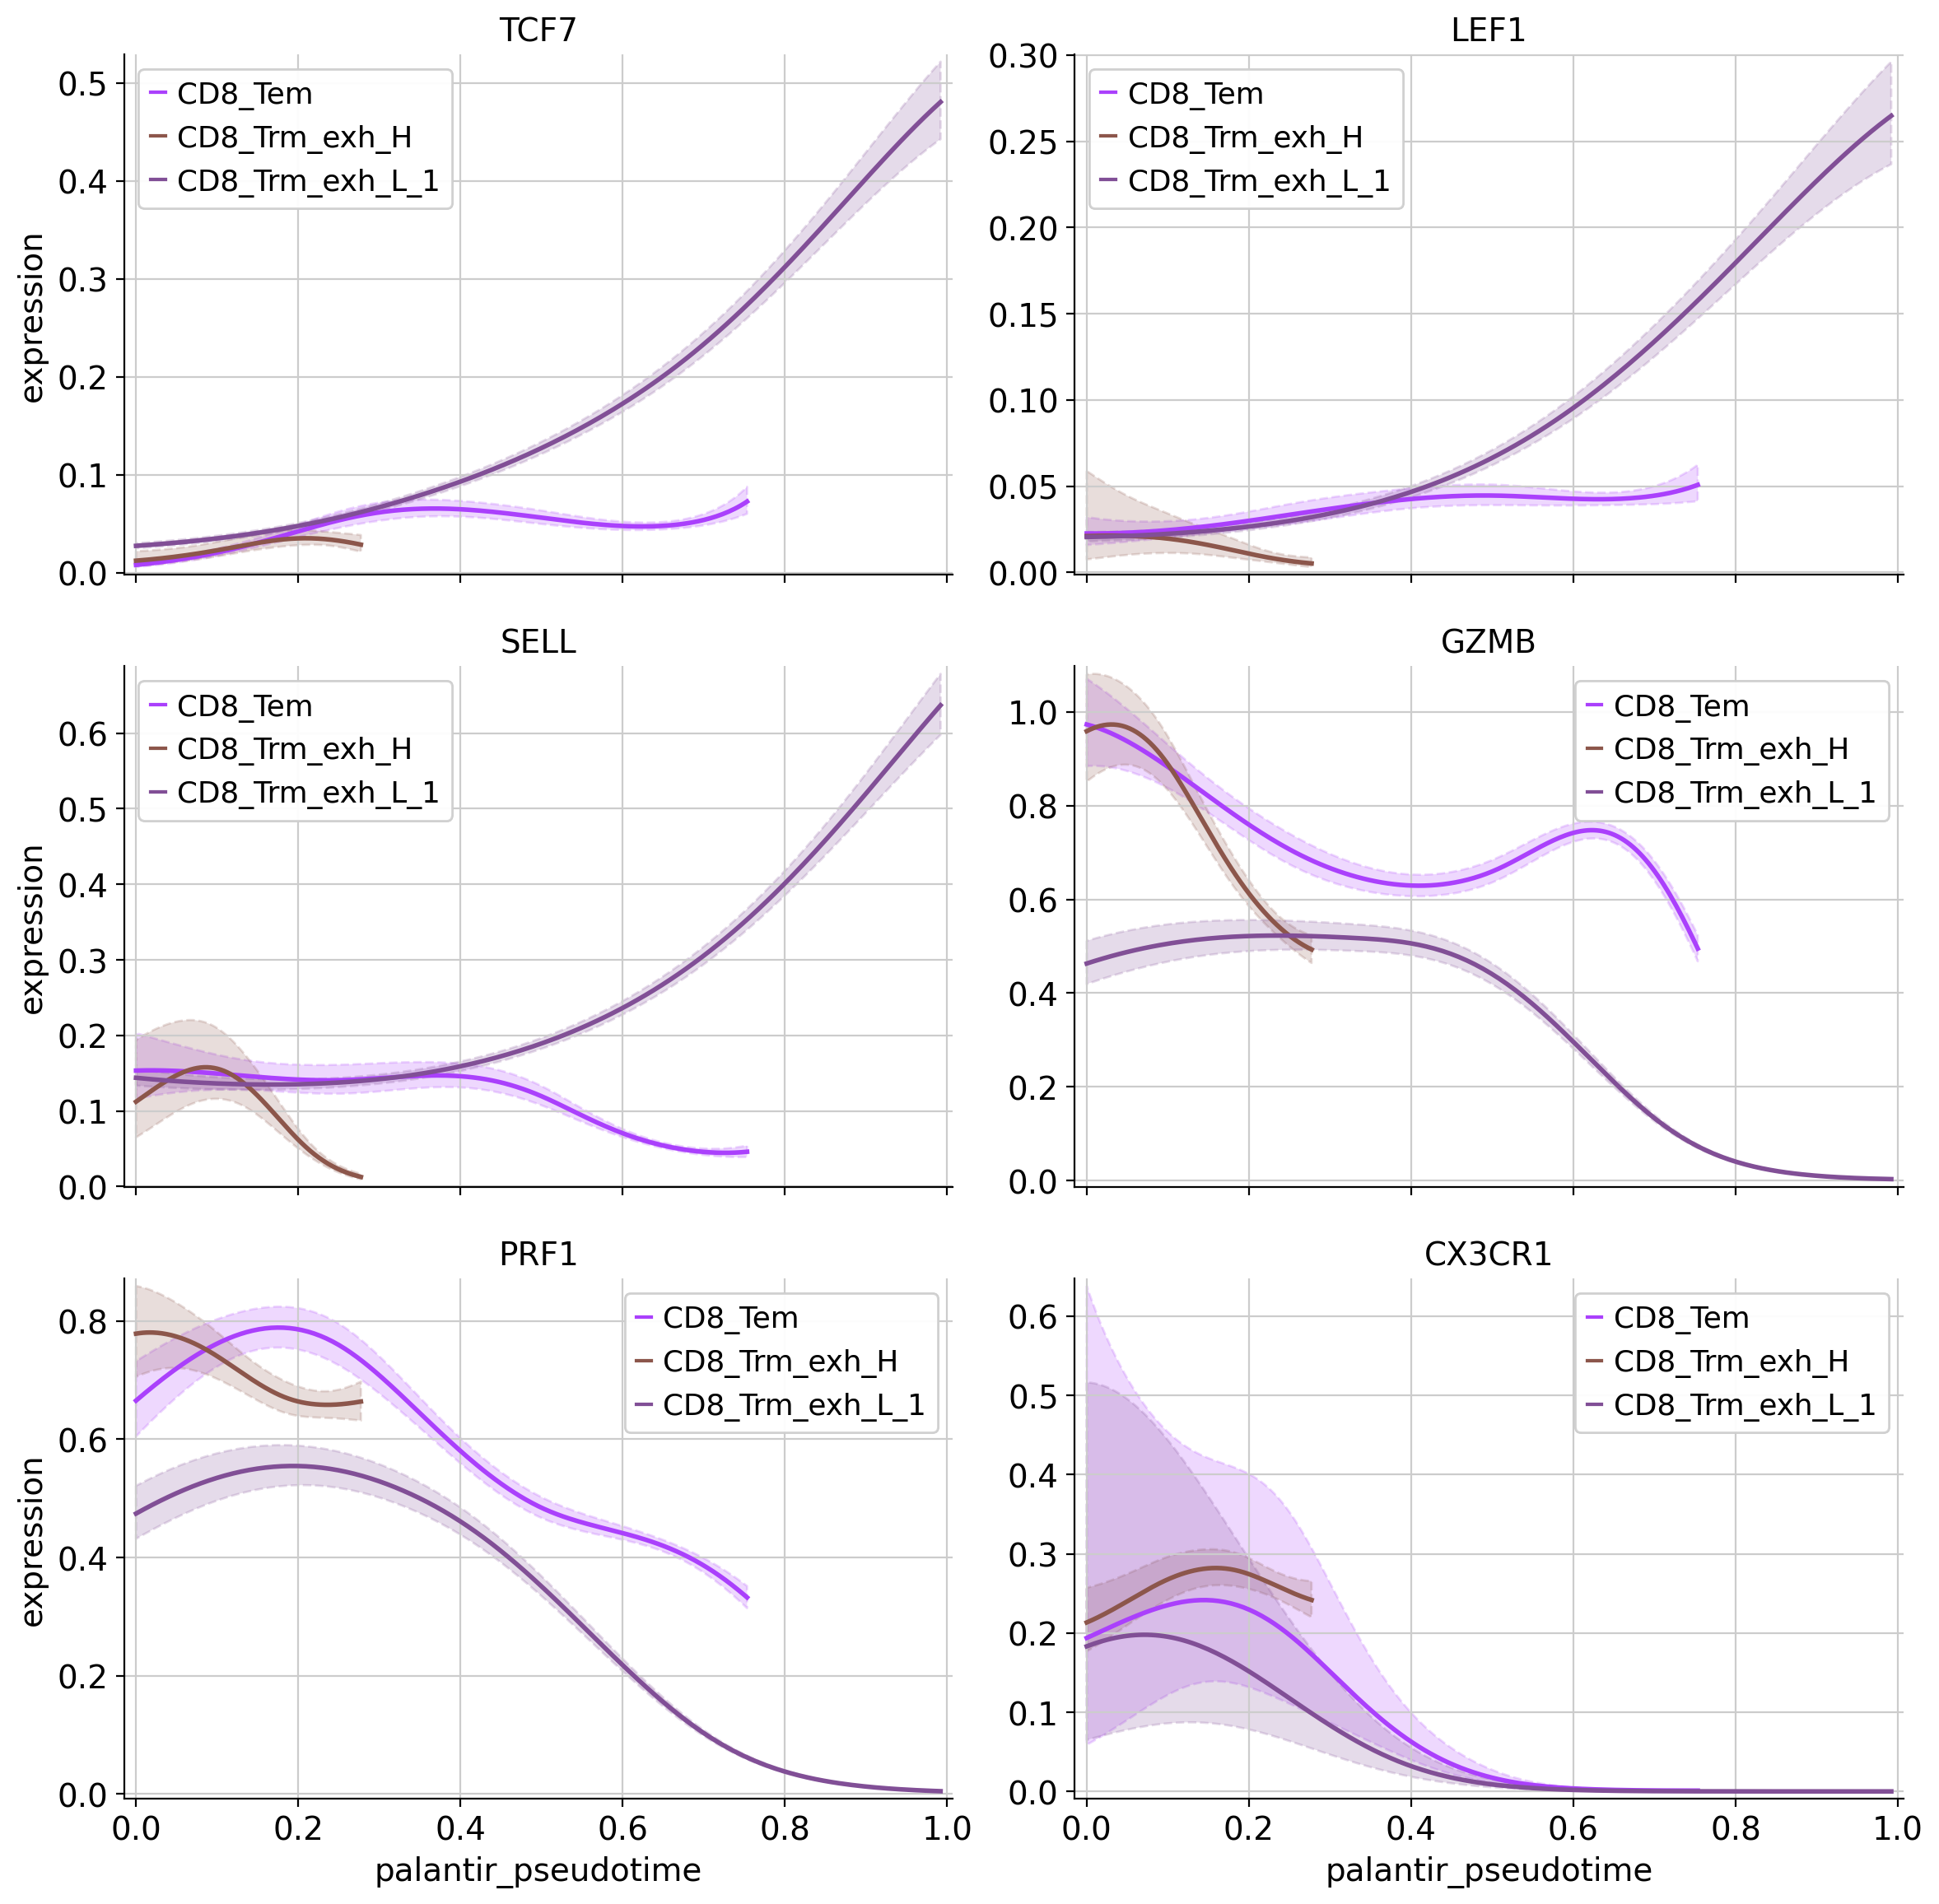

In [ ]:
# Gene expression trends along each lineage (CellRank GAM model)
# cr.models.GAM is built on adata (full gene expression), not adata_pca.
cd8_genes = [
    "TCF7", "LEF1", "SELL",            # stem / memory
    "GZMB", "PRF1", "CX3CR1",          # effector / cytotoxic
    "PDCD1", "HAVCR2", "TOX", "ENTPD1", # exhaustion
]
cd8_genes = [g for g in cd8_genes if g in adata.var_names]
print("Genes available for trends:", cd8_genes)

if cd8_genes:
    adata.obs["palantir_pseudotime"] = (
        adata_pca.obs["palantir_pseudotime"].reindex(adata.obs_names)
    )

    model = cr.models.GAM(adata)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        cr.pl.gene_trends(
            adata,
            model=model,
            genes=cd8_genes[:6],
            same_plot=True,
            ncols=2,
            time_key="palantir_pseudotime",
            hide_cells=True,
        )


100%|██████████| 10/10 [00:02<00:00,  3.51gene/s]


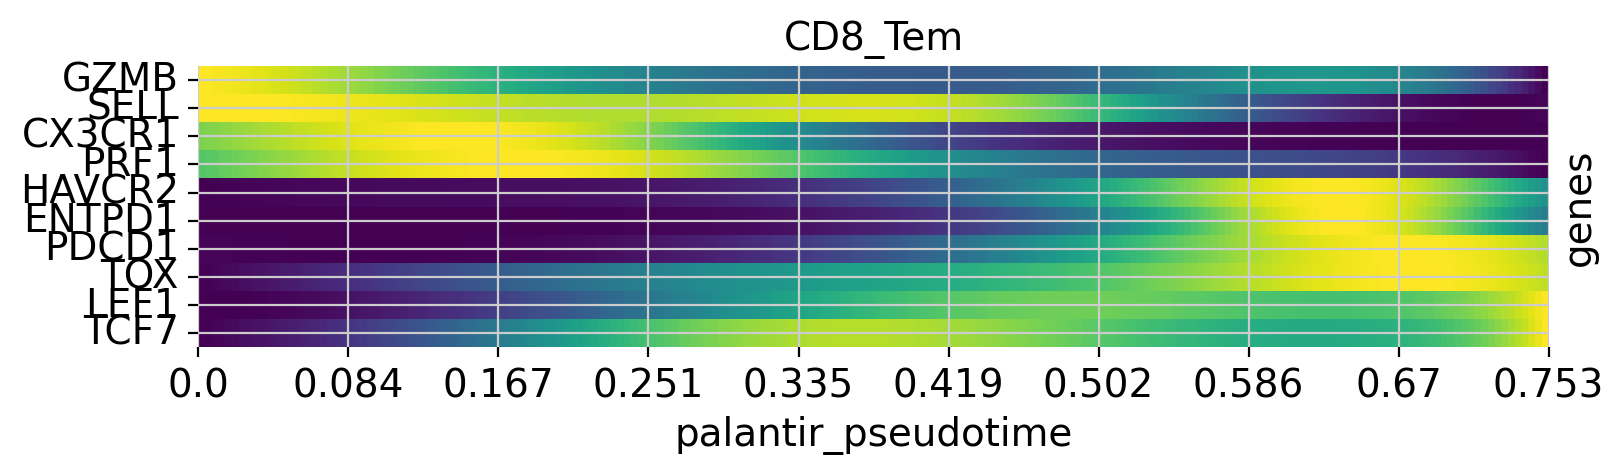

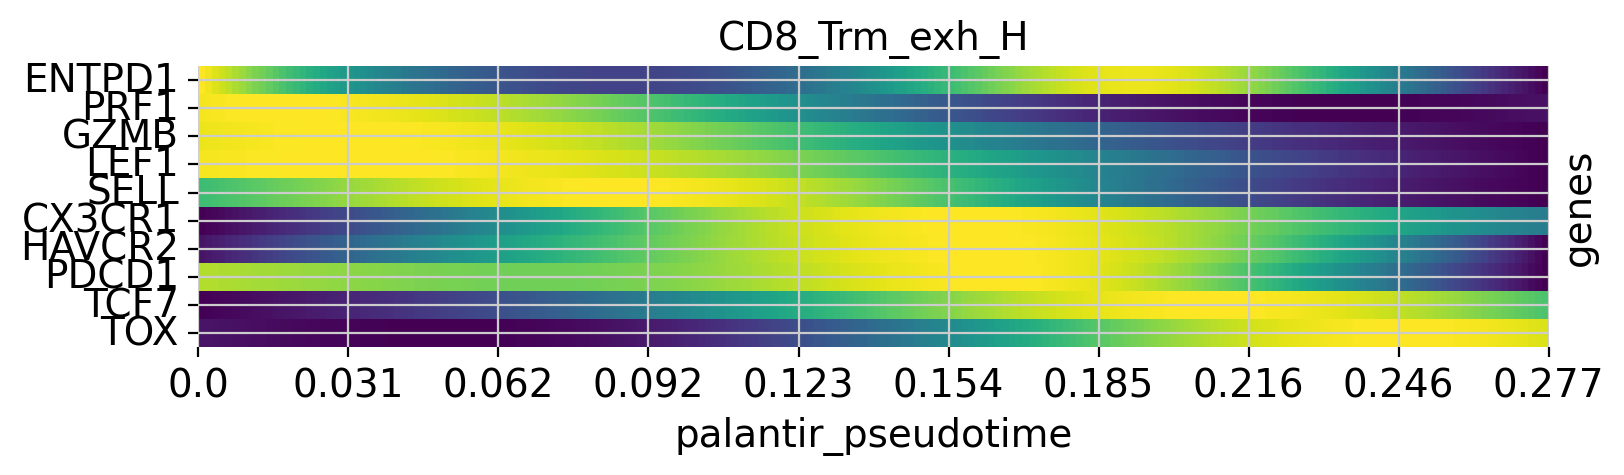

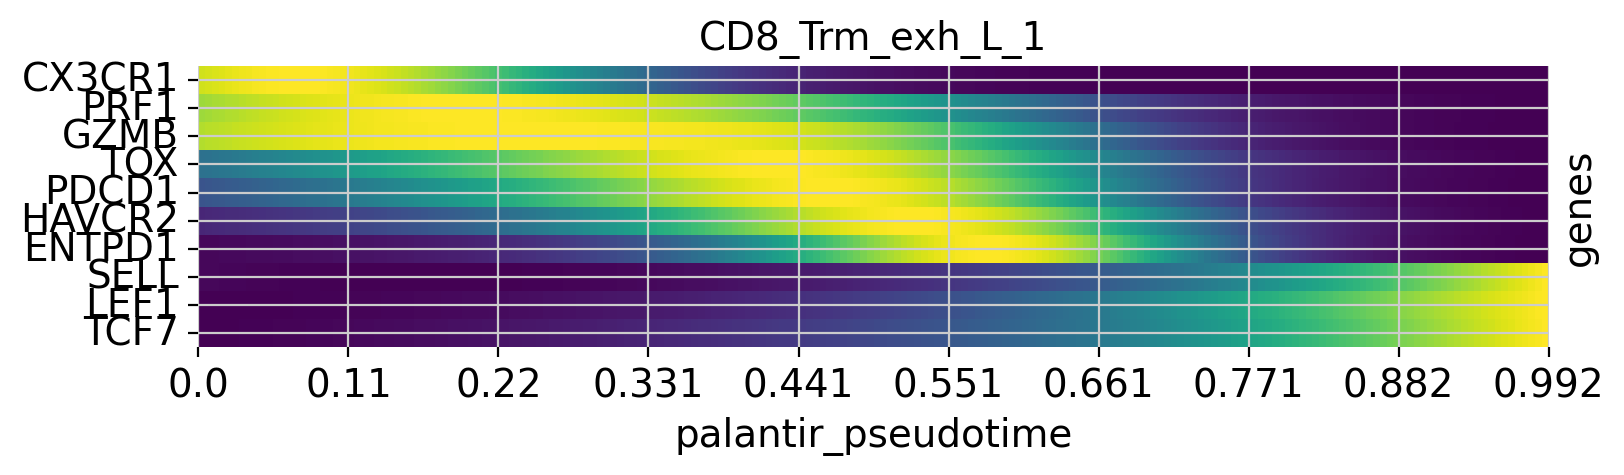

In [ ]:
if cd8_genes:
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        cr.pl.heatmap(
            adata,
            model=model,
            genes=cd8_genes,
            lineages=terminal_lineages,
            time_key="palantir_pseudotime",
            cbar=False,
            show_all_genes=True,
        )


## 9. Gene expression trends along pseudotime
Palantir can model smooth gene expression trends with GAMs.

In [ ]:
# Copy Palantir results into the full GEX adata for trend computation
adata.obs["palantir_pseudotime"] = pr_res.pseudotime.reindex(adata.obs_names)
adata.obs["palantir_entropy"]    = pr_res.entropy.reindex(adata.obs_names)

# Store fate probabilities so select_branch_cells can build branch_masks
adata.obsm["palantir_fate_probabilities"] = pr_res.branch_probs.reindex(adata.obs_names)
palantir.presults.select_branch_cells(adata, eps=0.0, q=0.01)

for term in pr_res.branch_probs.columns:
    adata.obs[f"fate_{term}"] = pr_res.branch_probs[term].reindex(adata.obs_names).values

genes_of_interest = [
    "TCF7",   # stem-like memory
    "LEF1",   # memory
    "SELL",   # naive / central memory
    "CX3CR1", # terminally differentiated effector
    "GZMB",   # cytotoxic effector
    "PRF1",   # cytotoxic
    "PDCD1",  # exhaustion (PD-1)
    "HAVCR2", # exhaustion (TIM-3)
    "TOX",    # exhaustion TF
    "ENTPD1", # exhausted CD39
]
genes_present = [g for g in genes_of_interest if g in adata.var_names]
print("Genes found:", genes_present)
print("branch_masks shape:", adata.obsm["branch_masks"].shape)


Genes found: ['TCF7', 'LEF1', 'SELL', 'CX3CR1', 'GZMB', 'PRF1', 'PDCD1', 'HAVCR2', 'TOX', 'ENTPD1']
branch_masks shape: (14957, 1)


In [ ]:
if genes_present:
    # Palantir 1.4.4 computes trends for every gene in adata;
    # subset to the genes of interest to keep runtime manageable.
    adata_trends = adata[:, genes_present].copy()
    gene_trends = palantir.presults.compute_gene_trends(
        adata_trends,
        pseudo_time_key="palantir_pseudotime",
    )
    print("Branches:", list(gene_trends.keys()))


LB6_ATGCGATCAACACCTA-1
[2026-05-07 14:01:55,066] [INFO    ] Using sparse Gaussian Process since n_landmarks (500) < n_samples (827) and rank = 1.0.
[2026-05-07 14:01:55,066] [INFO    ] Using covariance function Matern52(ls=1.0).
[2026-05-07 14:01:56,449] [INFO    ] Sigma interpreted as element-wise standard deviation.
Branches: ['LB6_ATGCGATCAACACCTA-1']


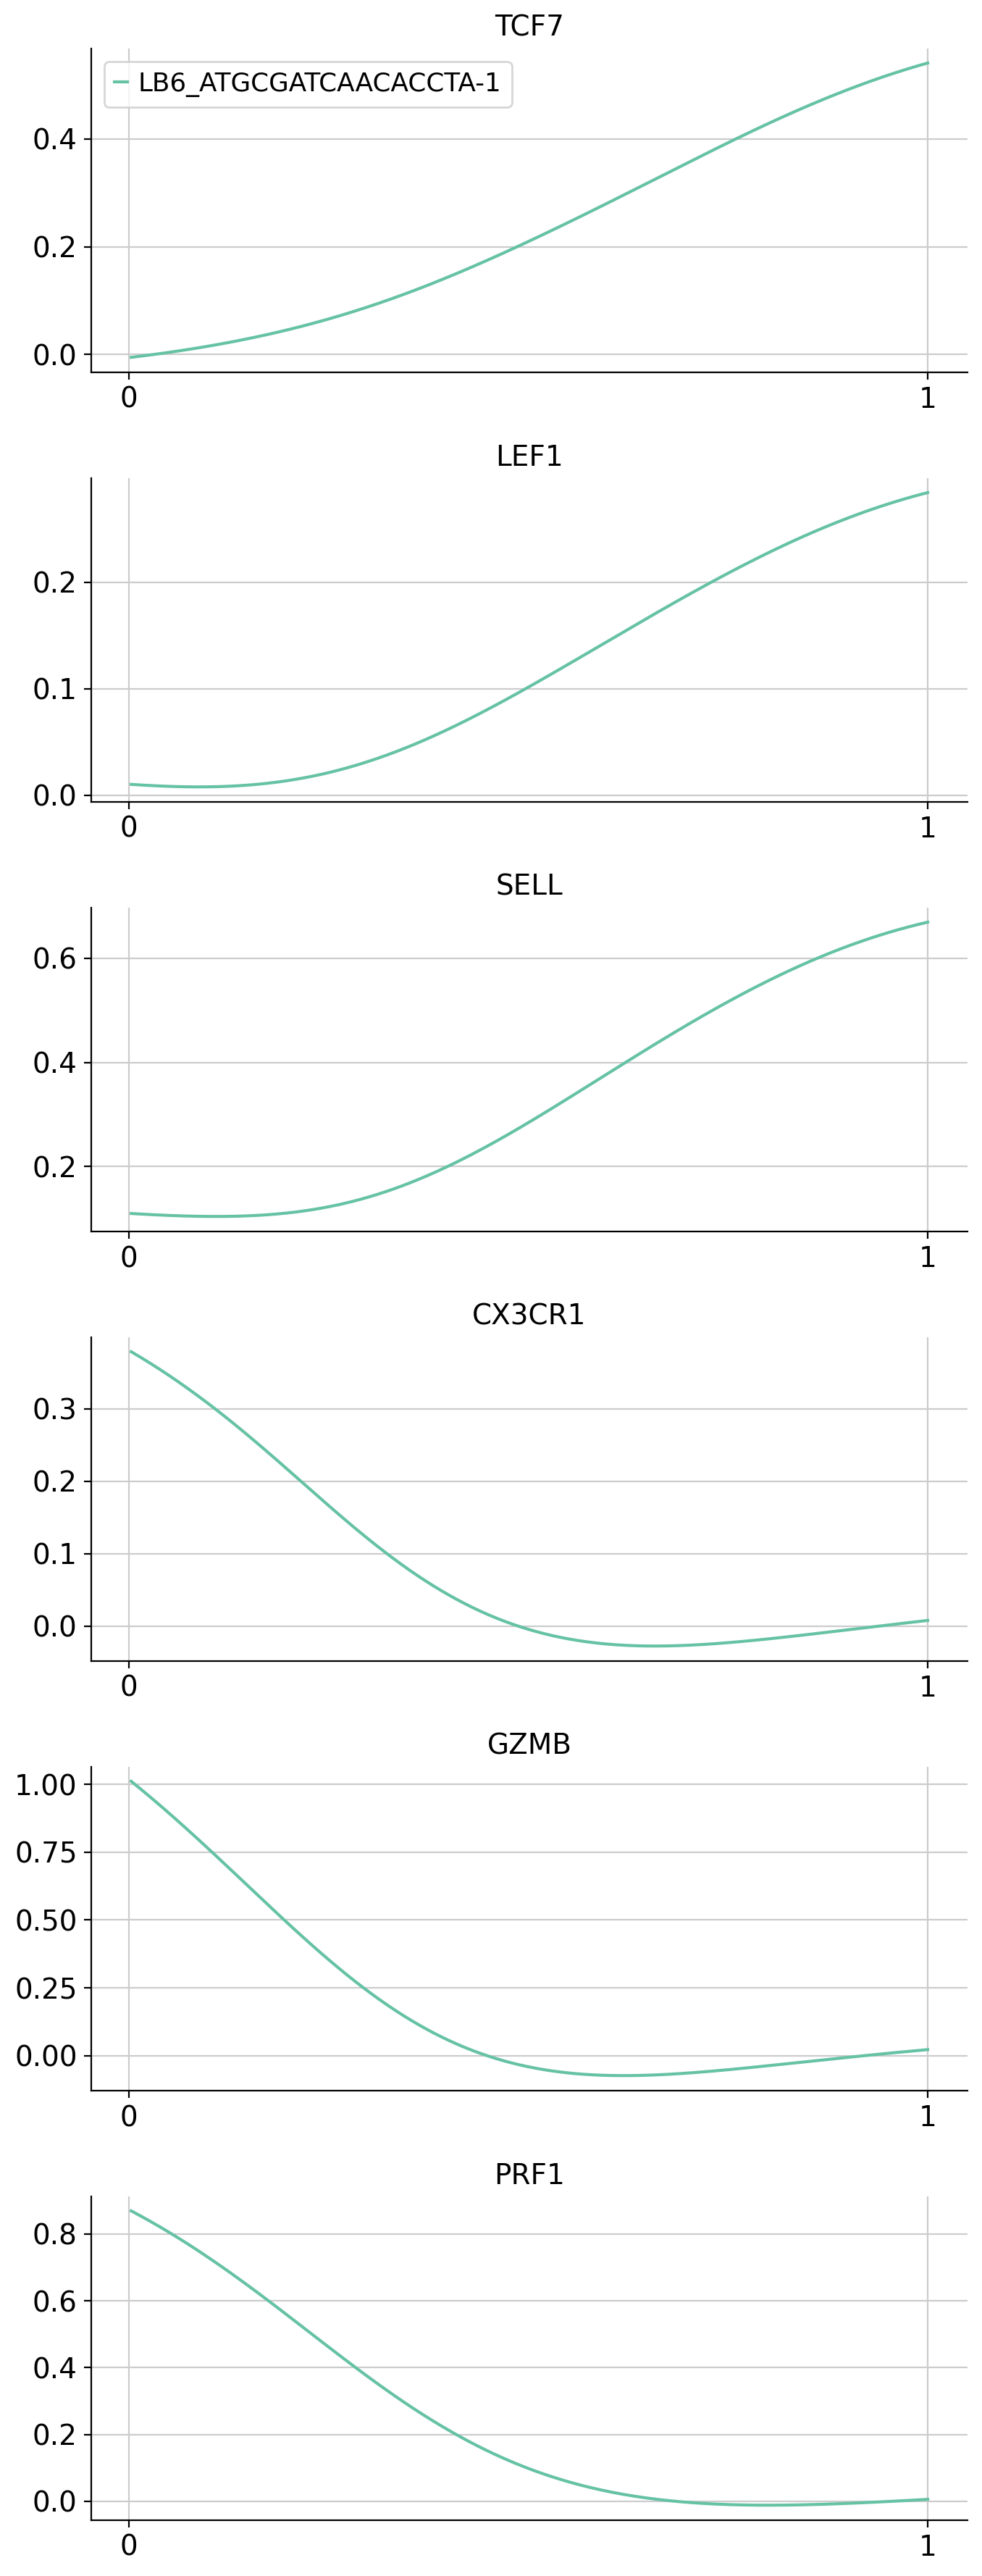

In [ ]:
if genes_present:
    palantir.plot.plot_gene_trends(gene_trends, genes=genes_present[:6])
    plt.tight_layout()
    plt.show()

## 10. Save results

In [ ]:
import os
os.makedirs("./data/Processed", exist_ok=True)

# Save pseudotime / entropy / fate back into the GEX AnnData
adata.write_h5ad("./data/Processed/CD8_palantir.h5ad")
print("Saved ./data/Processed/CD8_palantir.h5ad")
print(adata.obs[["palantir_pseudotime", "palantir_entropy"] + fate_cols].head())

Saved ./data/Processed/CD8_palantir.h5ad
                        palantir_pseudotime  palantir_entropy  \
LT1_AAACGGGCATCGGTTA-1             0.705896               0.0   
LT1_AAAGTAGGTAGCACGA-1             0.630163               0.0   
LT1_AAAGTAGGTCGAAAGC-1             0.698915               0.0   
LT1_AACCGCGCAGTGAGTG-1             0.705345               0.0   
LT1_AACTCAGAGGCATTGG-1             0.714260               0.0   

                        fate_LB6_ATGCGATCAACACCTA-1  
LT1_AAACGGGCATCGGTTA-1                          1.0  
LT1_AAAGTAGGTAGCACGA-1                          1.0  
LT1_AAAGTAGGTCGAAAGC-1                          1.0  
LT1_AACCGCGCAGTGAGTG-1                          1.0  
LT1_AACTCAGAGGCATTGG-1                          1.0  
